# Gaussian Mixture Models from Scratch

A Gaussian mixture model describes a dataset as coming from $C$ overlapping Gaussian clouds. Every point is
assumed to have been produced by first picking a component $c$ with probability $\pi_c$, then drawing a point
from that component's Gaussian. The density of the mixture is

$$p(\mathbf{x}) = \sum_{c=1}^{C} \pi_c \, \mathcal{N}(\mathbf{x} \mid \boldsymbol\mu_c, \Sigma_c),
\qquad \pi_c \ge 0, \qquad \sum_{c=1}^{C} \pi_c = 1.$$

The component that generated any particular point is never observed, so the parameters cannot be estimated by
counting. They are fitted by **Expectation-Maximisation**: guess the parameters, work out how responsible each
component is for each point, then re-estimate the parameters using those responsibilities as weights, and repeat.

Two things distinguish this from k-means:

- **Soft assignment.** k-means gives every point to exactly one centroid. A GMM gives every point a probability
  vector over the components, so a point sitting between two clusters is recorded as genuinely ambiguous
  rather than being forced into one of them.
- **Cluster shape.** k-means minimises squared distance to a centroid, which implicitly assumes clusters that
  are spherical and of similar size. A GMM with a full covariance $\Sigma_c$ per component fits an
  ellipse of arbitrary width, height and orientation to each cluster.

The second point is the interesting one on this dataset, and this notebook makes it visible by drawing the
fitted covariance ellipses.

What gets built here:

- `kmeans`, a short inline implementation, used both as a baseline and as the initialiser for EM.
- `log_gaussian` and `logsumexp`, the numerical core. In 13 dimensions the raw Gaussian densities are small
  enough that a naive product of them underflows to exactly zero in float64. That is demonstrated below with
  the actual numbers rather than asserted.
- `GMM`, a class fitted by EM, supporting `covariance_type` of `'full'`, `'diagonal'` and `'spherical'`.
- Model selection by BIC over $C = 1 \dots 8$, and a comparison of the three covariance types.

The data is UCI Wine. The cultivar labels are held back throughout the fit and only used at the end to score
the clustering.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from itertools import permutations
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

SEED = 42
np.random.seed(SEED)

# one colour per component / cluster, used everywhere below
COLOURS = ['#2a78d6', '#eb6834', '#1baf7a']

print('numpy', np.__version__)

numpy 1.26.4


## The data

UCI Wine (`id=109`): 178 wines from three cultivars grown in the same region of Italy, each described by 13
continuous chemical measurements — alcohol, flavanoids, colour intensity, proline and so on. There are no
missing values. The cultivars are unbalanced at 59 / 71 / 48.

The next cell downloads the data, puts the features in `X_raw` and the cultivar labels in `y` relabelled to
`0, 1, 2`, then standardises every column to zero mean and unit variance to produce `X`. Standardising matters
here for two reasons. Proline runs in the hundreds while hue runs around 1, so on the raw scale a squared
distance is almost entirely proline and k-means would cluster on that single variable. It also keeps the
covariance matrices well conditioned, which the Cholesky factorisation below depends on.

`y` is not passed to any fitting routine. It is used once, at the end, to check what the clusters correspond to.

In [2]:
wine = fetch_ucirepo(id=109)

feature_names = list(wine.data.features.columns)
X_raw = wine.data.features.to_numpy(dtype=float)
y_raw = wine.data.targets.to_numpy().ravel().astype(int)

# relabel cultivars 1,2,3 -> 0,1,2
cultivars = np.unique(y_raw)
y = np.searchsorted(cultivars, y_raw)
class_labels = ['Cultivar %d' % c for c in cultivars]

# standardise every column
X = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)

N, D = X.shape
C_TRUE = len(cultivars)

print('X', X.shape, '  features', D, '  wines', N)
print('missing values:', int(np.isnan(X_raw).sum()))
for c in range(C_TRUE):
    print('%-12s %3d wines' % (class_labels[c], np.sum(y == c)))
print()
print('raw column means  ', np.round(X_raw.mean(axis=0), 2))
print('standardised means', np.round(X.mean(axis=0), 6))
print('standardised sds  ', np.round(X.std(axis=0), 6))
print()
print(wine.data.features.head())

X (178, 13)   features 13   wines 178
missing values: 0
Cultivar 1    59 wines
Cultivar 2    71 wines
Cultivar 3    48 wines

raw column means   [1.3000e+01 2.3400e+00 2.3700e+00 1.9490e+01 9.9740e+01 2.3000e+00
 2.0300e+00 3.6000e-01 1.5900e+00 5.0600e+00 9.6000e-01 2.6100e+00
 7.4689e+02]
standardised means [-0. -0. -0. -0. -0.  0. -0.  0. -0.  0.  0.  0. -0.]
standardised sds   [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

   Alcohol  Malicacid   Ash  Alcalinity_of_ash  Magnesium  Total_phenols  \
0    14.23       1.71  2.43               15.6        127           2.80   
1    13.20       1.78  2.14               11.2        100           2.65   
2    13.16       2.36  2.67               18.6        101           2.80   
3    14.37       1.95  2.50               16.8        113           3.85   
4    13.24       2.59  2.87               21.0        118           2.80   

   Flavanoids  Nonflavanoid_phenols  Proanthocyanins  Color_intensity   Hue  \
0        3.06                  0.28   

## k-means, and why it is the limiting case of a GMM

`kmeans` below is the whole algorithm in about twenty lines. Centroids are seeded by k-means++ (first centre
uniformly at random, each subsequent centre drawn with probability proportional to squared distance from the
nearest existing centre), then the two steps alternate: assign every point to its nearest centroid, move every
centroid to the mean of the points assigned to it. It stops when the centroids stop moving. `inertia` is the
total within-cluster squared distance, the quantity being minimised.

k-means is exactly what a GMM becomes in a particular limit. Fix every covariance to $\Sigma_c = \sigma^2 I$
and let $\sigma^2 \to 0$. The responsibility of component $c$ for point $i$ is

$$\gamma_{ic} = \frac{\pi_c \exp\!\left(-\lVert \mathbf{x}_i - \boldsymbol\mu_c \rVert^2 / 2\sigma^2\right)}
{\sum_j \pi_j \exp\!\left(-\lVert \mathbf{x}_i - \boldsymbol\mu_j \rVert^2 / 2\sigma^2\right)}.$$

Dividing through by the largest term, every ratio has the form
$\exp(-(\lVert \mathbf{x}_i - \boldsymbol\mu_c \rVert^2 - \lVert \mathbf{x}_i - \boldsymbol\mu_{c^*} \rVert^2)/2\sigma^2)$
where $c^*$ is the nearest centre. As $\sigma^2 \to 0$ that exponent goes to $-\infty$ for every component
except the nearest one, so

$$\gamma_{ic} \longrightarrow \begin{cases} 1 & c = \arg\min_j \lVert \mathbf{x}_i - \boldsymbol\mu_j \rVert^2 \\ 0 & \text{otherwise,}\end{cases}$$

which is the k-means assignment step. Substituting those 0/1 responsibilities into the GMM mean update
$\boldsymbol\mu_c = \frac{1}{N_c}\sum_i \gamma_{ic}\mathbf{x}_i$ leaves the plain mean of the assigned points,
which is the k-means centroid update.

So a GMM is k-means with two constraints removed: the responsibilities are allowed to be fractional, and the
covariance is allowed to be something other than a vanishing multiple of the identity. Everything a GMM buys
comes from those two relaxations.

In [3]:
def kmeans(X, k, seed=SEED, n_iter=300):
    rng = np.random.RandomState(seed)
    # k-means++ seeding
    centres = [X[rng.randint(len(X))]]
    for _ in range(k - 1):
        d2 = ((X[:, None, :] - np.array(centres)[None, :, :]) ** 2).sum(2).min(1)
        centres.append(X[rng.choice(len(X), p=d2 / d2.sum())])
    centres = np.array(centres)

    labels = np.zeros(len(X), dtype=int)
    for _ in range(n_iter):
        d2 = ((X[:, None, :] - centres[None, :, :]) ** 2).sum(2)
        labels = np.argmin(d2, axis=1)
        new = np.array([X[labels == c].mean(0) if np.any(labels == c) else centres[c]
                        for c in range(k)])
        if np.allclose(new, centres):
            break
        centres = new

    inertia = ((X - centres[labels]) ** 2).sum()
    return centres, labels, inertia


km_centres, km_labels, km_inertia = kmeans(X, C_TRUE)

print('k-means with k=%d' % C_TRUE)
print('inertia %.2f' % km_inertia)
for c in range(C_TRUE):
    print('  cluster %d: %3d points' % (c, np.sum(km_labels == c)))

k-means with k=3
inertia 1279.97
  cluster 0:  64 points
  cluster 1:  51 points
  cluster 2:  63 points


## The multivariate normal, and why the computation has to happen in log space

The density of a $D$-dimensional Gaussian is

$$\mathcal{N}(\mathbf{x} \mid \boldsymbol\mu, \Sigma) =
\frac{1}{(2\pi)^{D/2}\,\lvert\Sigma\rvert^{1/2}}
\exp\!\left(-\tfrac{1}{2}(\mathbf{x}-\boldsymbol\mu)^\top \Sigma^{-1} (\mathbf{x}-\boldsymbol\mu)\right),$$

and its logarithm is

$$\log \mathcal{N}(\mathbf{x} \mid \boldsymbol\mu, \Sigma) =
-\tfrac{1}{2}\left[D\log 2\pi + \log\lvert\Sigma\rvert + (\mathbf{x}-\boldsymbol\mu)^\top \Sigma^{-1} (\mathbf{x}-\boldsymbol\mu)\right].$$

`log_gaussian` computes the right-hand side for every row of `X` at once. It never forms $\Sigma^{-1}$ or
computes a determinant directly. Instead it takes the Cholesky factor $\Sigma = LL^\top$ with
`np.linalg.cholesky`, which gives both pieces cheaply and stably:

- the quadratic form becomes $\lVert L^{-1}(\mathbf{x}-\boldsymbol\mu)\rVert^2$, obtained with one triangular
  solve, so no matrix is inverted;
- $\log\lvert\Sigma\rvert = 2\sum_d \log L_{dd}$, a sum of logs rather than a product of eigenvalues that would
  itself underflow.

Cholesky also fails loudly, with `LinAlgError`, if $\Sigma$ is not positive definite. That failure is a useful
signal rather than a nuisance — it is what a collapsing component looks like.

`logsumexp` implements the identity

$$\log \sum_k \exp(a_k) = a_{\max} + \log \sum_k \exp(a_k - a_{\max}), \qquad a_{\max} = \max_k a_k.$$

Both sides are equal exactly, but the right-hand side computes every exponential of a number that is at most
zero, so the largest term is $\exp(0) = 1$ and nothing overflows, while terms that do underflow to zero are the
ones that were negligible anyway. This is how the mixture density $\sum_c \pi_c \mathcal{N}(\cdot)$ gets summed
without ever leaving log space.

The next two cells show the underflow concretely on this dataset, using the k-means clusters as stand-in
Gaussian parameters.

In [4]:
def logsumexp(a, axis):
    m = np.max(a, axis=axis, keepdims=True)
    return m + np.log(np.sum(np.exp(a - m), axis=axis, keepdims=True))


def log_gaussian(X, mean, cov):
    D = X.shape[1]
    L = np.linalg.cholesky(cov)
    diff = X - mean
    sol = np.linalg.solve(L, diff.T)              # L^-1 (x - mu), shape (D, N)
    maha = (sol ** 2).sum(0)                      # squared Mahalanobis distance
    logdet = 2.0 * np.sum(np.log(np.diag(L)))     # log|Sigma|
    return -0.5 * (D * np.log(2 * np.pi) + logdet + maha)


# stand-in mixture parameters taken straight from the k-means clusters
demo_weights = np.array([np.mean(km_labels == c) for c in range(C_TRUE)])
demo_means = km_centres.copy()
demo_covs = np.array([np.cov(X[km_labels == c].T) + 1e-6 * np.eye(D) for c in range(C_TRUE)])

log_comp = np.column_stack([log_gaussian(X, demo_means[c], demo_covs[c]) for c in range(C_TRUE)])
log_mix = logsumexp(np.log(demo_weights)[None, :] + log_comp, axis=1).ravel()
dens = np.exp(log_mix)

# the naive computation: multiply the per-point densities together
raw_prod = np.prod(dens)
cum_prod = np.cumprod(dens)
first_zero = int(np.argmax(cum_prod == 0.0)) if np.any(cum_prod == 0.0) else -1

print('per-point mixture density')
print('  largest  %.6e' % dens.max())
print('  smallest %.6e' % dens.min())
print()
print('smallest positive float64 (subnormal): %.3e' % 5e-324)
print('naive product over all %d points: %.6e' % (N, raw_prod))
print('running product first hits exactly 0.0 after %d of %d points' % (first_zero + 1, N))
print()
print('same quantity in log space, sum of logs: %.4f' % log_mix.sum())
print('exponentiating that back: %.3e  (this is what the product should have been)' % np.exp(log_mix.sum()))
print()
print('single worst component log density: %.2f  ->  exp = %.3e'
      % (log_comp.min(), np.exp(log_comp.min())))

per-point mixture density
  largest  1.916233e-03
  smallest 7.414506e-12

smallest positive float64 (subnormal): 4.941e-324
naive product over all 178 points: 0.000000e+00
running product first hits exactly 0.0 after 68 of 178 points

same quantity in log space, sum of logs: -2089.8732
exponentiating that back: 0.000e+00  (this is what the product should have been)

single worst component log density: -282.76  ->  exp = 1.582e-123


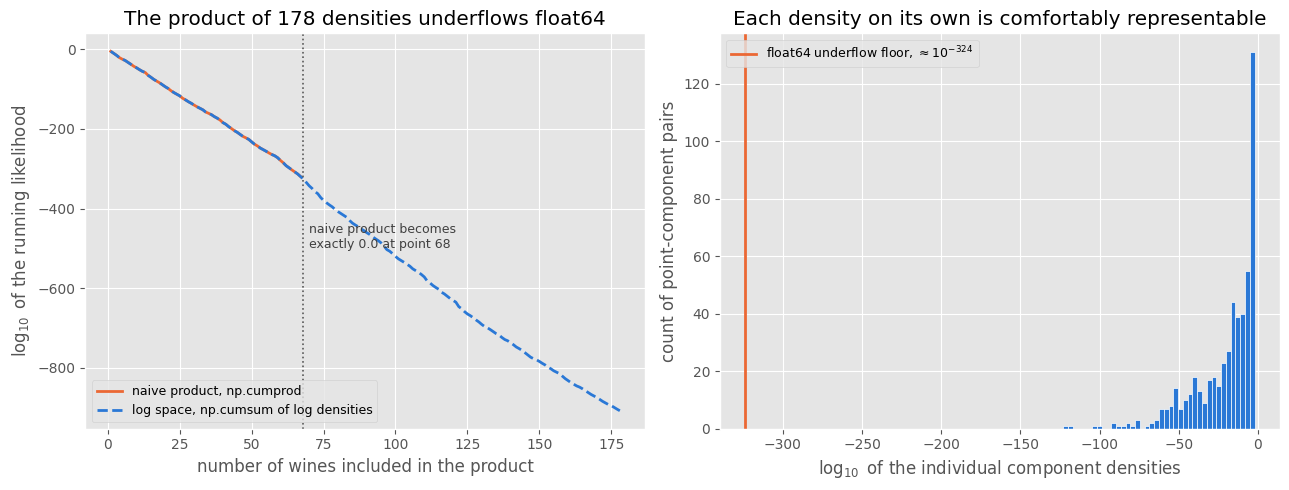

every one of the 534 individual densities is representable on its own;
it is the product across points that is not.


In [5]:
n_pts = np.arange(1, N + 1)
log_cum = np.cumsum(log_mix)                       # log-space running total
with np.errstate(divide='ignore'):
    log10_naive = np.log10(cum_prod)               # -inf once the product underflows
alive = np.isfinite(log10_naive)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(n_pts[alive], log10_naive[alive], color=COLOURS[1], lw=2,
           label='naive product, np.cumprod')
ax[0].plot(n_pts, log_cum / np.log(10), color=COLOURS[0], lw=2, ls='--',
           label='log space, np.cumsum of log densities')
ax[0].axvline(first_zero + 1, color='0.35', lw=1.2, ls=':')
ax[0].text(first_zero + 3, log_cum[-1] / np.log(10) * 0.55,
           'naive product becomes\nexactly 0.0 at point %d' % (first_zero + 1), fontsize=9, color='0.25')
ax[0].set_xlabel('number of wines included in the product')
ax[0].set_ylabel(r'$\log_{10}$ of the running likelihood')
ax[0].set_title('The product of 178 densities underflows float64')
ax[0].legend(loc='lower left', fontsize=9)

ax[1].hist(log_comp.ravel() / np.log(10), bins=40, color=COLOURS[0], edgecolor='white')
ax[1].axvline(-323.6, color=COLOURS[1], lw=2,
              label=r'float64 underflow floor, $\approx 10^{-324}$')
ax[1].set_xlabel(r'$\log_{10}$ of the individual component densities')
ax[1].set_ylabel('count of point-component pairs')
ax[1].set_title('Each density on its own is comfortably representable')
ax[1].legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

print('every one of the %d individual densities is representable on its own;' % log_comp.size)
print('it is the product across points that is not.')

## Expectation-Maximisation

The parameters are $\theta = \{\pi_c, \boldsymbol\mu_c, \Sigma_c\}_{c=1}^{C}$ and the objective is the
log-likelihood of the observed data,

$$\log L(\theta) = \sum_{i=1}^{N} \log \sum_{c=1}^{C} \pi_c\,\mathcal{N}(\mathbf{x}_i \mid \boldsymbol\mu_c, \Sigma_c).$$

The log of a sum does not separate, so there is no closed-form maximiser. EM gets around this by alternating
between two steps that each do have a closed form.

**E-step.** Compute the responsibility $\gamma_{ic}$, the posterior probability that component $c$ generated
point $i$, given the current parameters:

$$\gamma_{ic} = \frac{\pi_c\,\mathcal{N}(\mathbf{x}_i \mid \boldsymbol\mu_c, \Sigma_c)}
{\sum_{j=1}^{C} \pi_j\,\mathcal{N}(\mathbf{x}_i \mid \boldsymbol\mu_j, \Sigma_j)}.$$

By construction $\sum_c \gamma_{ic} = 1$ for every $i$. In the code this is done as a subtraction in log space,
`log_resp = log_p - logsumexp(log_p, axis=1)`, and the denominator computed there is also the per-point
log-likelihood, so the E-step returns both.

**M-step.** Treating the responsibilities as fixed, define the effective number of points assigned to
component $c$ as $N_c = \sum_{i=1}^{N} \gamma_{ic}$, with $\sum_c N_c = N$. The updates are

$$\pi_c = \frac{N_c}{N}, \qquad
\boldsymbol\mu_c = \frac{1}{N_c}\sum_{i=1}^{N} \gamma_{ic}\,\mathbf{x}_i, \qquad
\Sigma_c = \frac{1}{N_c}\sum_{i=1}^{N} \gamma_{ic}\,(\mathbf{x}_i - \boldsymbol\mu_c)(\mathbf{x}_i - \boldsymbol\mu_c)^\top.$$

These are exactly the ordinary sample mean and sample covariance, with each point weighted by how responsible
the component is for it. A point with $\gamma_{ic} = 0.9$ contributes nine times as much to component $c$'s mean
and covariance as a point with $\gamma_{ic} = 0.1$. If the responsibilities were hard 0/1 these would be the
plain mean and covariance of the assigned subset, which is the k-means limit described earlier.

**The guarantee.** Each EM iteration is guaranteed never to decrease $\log L$. That is the property worth
knowing, and the code asserts it directly by checking `np.diff(self.history)`. The honest caveat is that this
guarantee is only about monotonicity: EM converges to a **local** optimum of the likelihood, and different
initialisations reach different local optima. It says nothing about finding the global one. That is exactly why
the initialisation below is taken from k-means rather than from random parameters.

**Covariance type.** `covariance_type` controls what shape each component is allowed to take, applied in
`_shape`:

- `'full'` — the whole $D \times D$ matrix. Arbitrary orientation and aspect ratio.
- `'diagonal'` — off-diagonal entries zeroed. Axis-aligned ellipses; the model cannot represent correlation
  between features within a component.
- `'spherical'` — a single variance times the identity. Circles.

**The ridge.** Every covariance gets `+ reg * np.eye(D)` with `reg = 1e-6`. This is not cosmetic. Maximum
likelihood for a GMM is an **ill-posed problem**: if one component places its mean exactly on a single data
point and shrinks its covariance towards zero, that point's density
$(2\pi\sigma^2)^{-D/2}$ grows without bound, and so does the total log-likelihood. The global maximum of the
likelihood is therefore $+\infty$ and is attained by a degenerate solution that has fit one point perfectly and
explained nothing. Any useful fit is a local optimum, not the global one. The ridge puts a floor under the
covariance so a component cannot collapse, and the Cholesky factorisation raises `LinAlgError` if one is on its
way there. This divergence is demonstrated numerically at the end of the notebook.

## The two steps, watched

The animation below runs the loop described above. In the **E-step** each point is coloured by its
responsibility vector

$$\gamma_{ik} = \frac{\pi_k\,\mathcal{N}(x_i \mid \mu_k, \Sigma_k)}{\sum_j \pi_j\,\mathcal{N}(x_i \mid \mu_j, \Sigma_j)}$$

and because the colours are genuinely blended, a wine that two components both half-claim comes
out a mixture of their colours. That is the visible difference from k-means, where every point is
one colour or another and nothing in between.

In the **M-step** each component refits to the points weighted by those responsibilities, so the
ellipses change shape and orientation rather than just moving.

The log-likelihood panel only ever goes up. That is the property EM guarantees: each step either
improves the likelihood or leaves it alone, which is what makes the loop safe to run to
convergence - though as the section on singularities later shows, converging is not the same as
converging somewhere sensible.

One change was needed to make this watchable. Seeded from k-means as the fit above is, the run
starts at $\log L = -2089.873$ and ends at $-2089.590$ - it is already at the answer, and nothing
moves. The animation therefore starts every $\Sigma_k$ at the identity, the unit sphere the
k-means limit corresponds to, so the ellipses have somewhere to travel from. It converges to the
same local optimum: $\log L = -2089.5903$ against the notebook's $-2089.5904$, with the mixing
weights identical to four decimals.

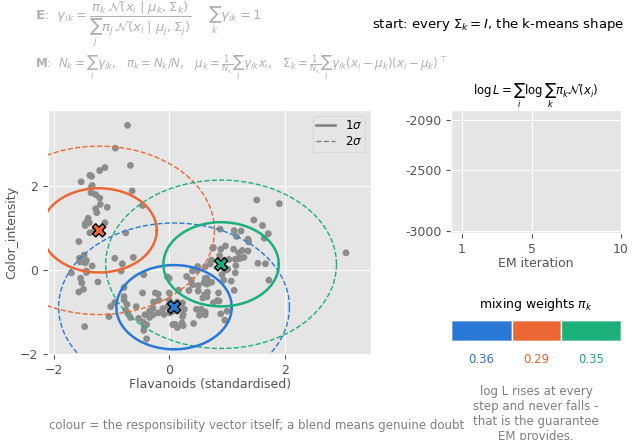

In [ ]:
from IPython.display import Image
Image(filename='../animations/gifs/gmm_em.gif')

In [6]:
class GMM:
    def __init__(self, n_components, covariance_type='full', max_iter=300,
                 tol=1e-7, reg=1e-6, init='kmeans', seed=SEED):
        self.n_components = n_components
        self.covariance_type = covariance_type
        self.max_iter = max_iter
        self.tol = tol
        self.reg = reg
        self.init = init
        self.seed = seed

    # constrain a covariance to the chosen type and add the ridge
    def _shape(self, S):
        D = S.shape[0]
        if self.covariance_type == 'diagonal':
            S = np.diag(np.diag(S))
        elif self.covariance_type == 'spherical':
            S = np.eye(D) * np.mean(np.diag(S))
        return S + self.reg * np.eye(D)

    def _initialise(self, X):
        N, D = X.shape
        C = self.n_components
        rng = np.random.RandomState(self.seed)

        if self.init == 'kmeans':
            centres, labels, _ = kmeans(X, C, seed=self.seed)
        else:
            labels = rng.randint(0, C, size=N)
            centres = np.array([X[labels == c].mean(0) if np.any(labels == c)
                                else X[rng.randint(N)] for c in range(C)])

        # means from the centroids, weights from the cluster proportions
        self.means = centres.copy()
        counts = np.array([max(np.sum(labels == c), 1) for c in range(C)], dtype=float)
        self.weights = counts / counts.sum()

        # covariances from the within-cluster scatter
        self.covariances = np.zeros((C, D, D))
        for c in range(C):
            Xc = X[labels == c]
            S = np.cov(Xc.T) if len(Xc) > D else np.cov(X.T)
            self.covariances[c] = self._shape(S)

    # log N(x_i | mu_c, Sigma_c) for every point and component, shape (N, C)
    def _log_gauss(self, X):
        return np.column_stack([log_gaussian(X, self.means[c], self.covariances[c])
                                for c in range(self.n_components)])

    # E-step: responsibilities and the total log-likelihood
    def _e_step(self, X):
        log_p = np.log(self.weights)[None, :] + self._log_gauss(X)
        log_norm = logsumexp(log_p, axis=1)        # per-point log-likelihood
        resp = np.exp(log_p - log_norm)
        return resp, float(log_norm.sum())

    # M-step: responsibility-weighted weights, means and covariances
    def _m_step(self, X, resp):
        N, D = X.shape
        Nc = resp.sum(axis=0) + 1e-12              # effective points per component
        self.weights = Nc / N
        self.means = (resp.T @ X) / Nc[:, None]
        for c in range(self.n_components):
            diff = X - self.means[c]
            S = (resp[:, c, None] * diff).T @ diff / Nc[c]
            self.covariances[c] = self._shape(S)

    def fit(self, X):
        self._initialise(X)
        self.history = []
        prev = -np.inf
        for _ in range(self.max_iter):
            resp, ll = self._e_step(X)
            self.history.append(ll)
            self._m_step(X, resp)
            if abs(ll - prev) < self.tol * abs(ll):
                break
            prev = ll
        # one final E-step so the stored responsibilities match the final parameters
        self.resp, self.loglik = self._e_step(X)
        self.history.append(self.loglik)
        self.history = np.array(self.history)
        self.n_iter = len(self.history)

        # EM never decreases the log-likelihood
        steps = np.diff(self.history)
        assert steps.min() > -1e-6 * abs(self.loglik), 'log-likelihood decreased'
        return self

    def predict_proba(self, X):
        return self._e_step(X)[0]

    def predict(self, X):
        return np.argmax(self._e_step(X)[0], axis=1)

    def score(self, X):
        return self._e_step(X)[1]

    # free parameters: mixing weights + means + covariance entries
    def n_parameters(self, D):
        C = self.n_components
        if self.covariance_type == 'full':
            per_cov = D * (D + 1) // 2
        elif self.covariance_type == 'diagonal':
            per_cov = D
        else:
            per_cov = 1
        return (C - 1) + C * D + C * per_cov

    def bic(self, X):
        return -2.0 * self.loglik + self.n_parameters(X.shape[1]) * np.log(len(X))


print('GMM defined')

GMM defined


## Fitting, and why the initialisation is taken from k-means

`_initialise` runs `kmeans` and reads the starting parameters off the result: `self.means` are the centroids,
`self.weights` are the cluster proportions, and each `self.covariances[c]` is the sample covariance of the
points in cluster $c$. The alternative, `init='random'`, assigns every point to a random component, which gives
three nearly identical means near the global mean and three nearly identical covariances close to the global
covariance.

The random start is worse for a specific reason rather than a vague one. If the components start out almost
identical, then $\gamma_{ic} \approx 1/C$ for every point, and the first M-step returns means that are all
close to the global mean again. EM has to break that near-symmetry from tiny numerical differences, and the
local optimum it drifts into is generally not the one that matches the cluster structure. In 13 dimensions
with 178 points there is a lot of room to end up somewhere poor.

The cell below fits `gmm_full` with `covariance_type='full'` and `C=3`, then checks the two properties that
have to hold: the responsibilities sum to 1 for every point, and the log-likelihood is non-decreasing across
iterations. It then refits from five random initialisations for comparison.

In [7]:
gmm_full = GMM(C_TRUE, covariance_type='full').fit(X)

resp_sums = gmm_full.resp.sum(axis=1)
assert np.allclose(resp_sums, 1.0), 'responsibilities do not sum to 1'

steps = np.diff(gmm_full.history)
assert steps.min() > -1e-6 * abs(gmm_full.loglik), 'log-likelihood decreased'

print('converged in %d iterations' % gmm_full.n_iter)
print('final log-likelihood      %.4f' % gmm_full.loglik)
print('BIC                       %.2f  (%d free parameters)'
      % (gmm_full.bic(X), gmm_full.n_parameters(D)))
print()
print('responsibility row sums: max deviation from 1 is %.2e' % np.abs(resp_sums - 1).max())
print('log-likelihood steps:    smallest %.3e   largest %.3e' % (steps.min(), steps.max()))
print('all steps non-negative:', bool(np.all(steps > -1e-9)))
print()
print('mixing weights   ', np.round(gmm_full.weights, 4))
print('effective points ', np.round(gmm_full.resp.sum(axis=0), 2))

# same model from random initialisations
random_runs = []
print()
print('random initialisation, five seeds:')
for s in range(5):
    g = GMM(C_TRUE, covariance_type='full', init='random', seed=s).fit(X)
    random_runs.append(g)
    print('  seed %d: %3d iterations, log-likelihood %.2f' % (s, g.n_iter, g.loglik))

best_random = max(r.loglik for r in random_runs)
print()
print('best random start  %.2f' % best_random)
print('k-means start      %.2f' % gmm_full.loglik)
print('k-means start is %.2f log-likelihood units higher' % (gmm_full.loglik - best_random))

converged in 9 iterations
final log-likelihood      -2089.5904
BIC                       5806.26  (314 free parameters)

responsibility row sums: max deviation from 1 is 1.55e-15
log-likelihood steps:    smallest 5.929e-05   largest 2.505e-01
all steps non-negative: True

mixing weights    [0.3571 0.2863 0.3566]
effective points  [63.57 50.96 63.47]

random initialisation, five seeds:


  seed 0:  49 iterations, log-likelihood -2176.38


  seed 1:  55 iterations, log-likelihood -2179.84


  seed 2:  38 iterations, log-likelihood -2177.58


  seed 3:  48 iterations, log-likelihood -2297.09


  seed 4:  32 iterations, log-likelihood -2196.53

best random start  -2176.38
k-means start      -2089.59
k-means start is 86.79 log-likelihood units higher


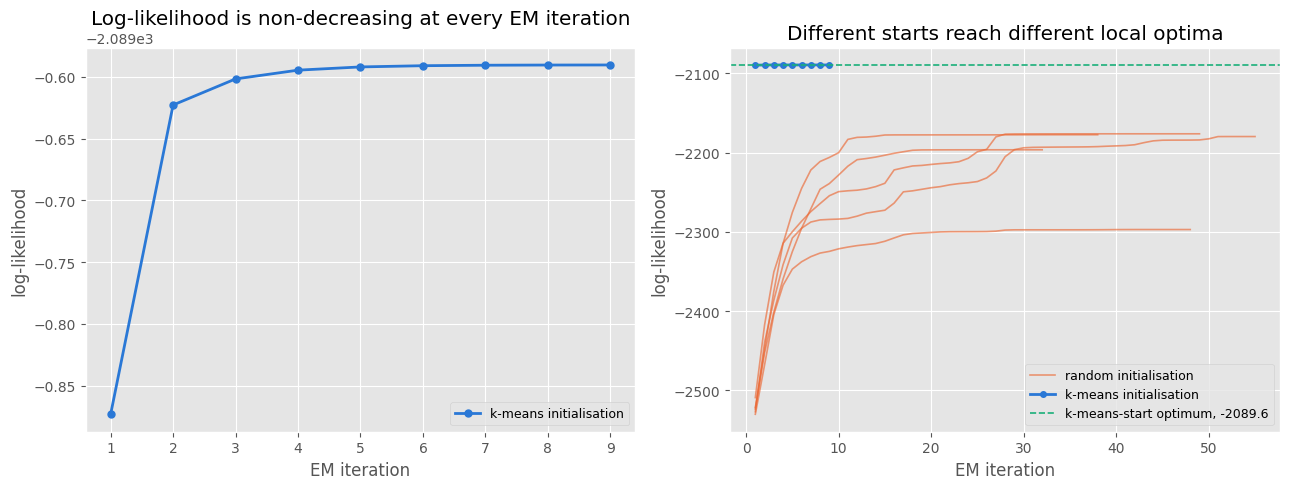

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

it = np.arange(1, gmm_full.n_iter + 1)
ax[0].plot(it, gmm_full.history, 'o-', color=COLOURS[0], lw=2, ms=5,
           label='k-means initialisation')
ax[0].set_xlabel('EM iteration')
ax[0].set_ylabel('log-likelihood')
ax[0].set_title('Log-likelihood is non-decreasing at every EM iteration')
ax[0].legend(loc='lower right', fontsize=9)

for i, g in enumerate(random_runs):
    ax[1].plot(np.arange(1, g.n_iter + 1), g.history, color=COLOURS[1], lw=1.2, alpha=0.65,
               label='random initialisation' if i == 0 else None)
ax[1].plot(it, gmm_full.history, 'o-', color=COLOURS[0], lw=2, ms=4,
           label='k-means initialisation')
ax[1].axhline(gmm_full.loglik, color=COLOURS[2], lw=1.2, ls='--',
              label='k-means-start optimum, %.1f' % gmm_full.loglik)
ax[1].set_xlabel('EM iteration')
ax[1].set_ylabel('log-likelihood')
ax[1].set_title('Different starts reach different local optima')
ax[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

## Matching the components to the cultivars

The fit never saw `y`, so component 0 has no reason to correspond to cultivar 0. `best_match` tries all
$3! = 6$ permutations of component labels and keeps the one with the highest agreement. This is the standard
way to score a clustering against known labels, and it is a fair comparison as long as the same procedure is
applied to both methods, which it is.

Agreement is reported rather than accuracy, since nothing was trained to predict anything.

In [9]:
def best_match(pred, truth, k):
    best_score, best_perm = -1.0, None
    for perm in permutations(range(k)):
        mapped = np.array(perm)[pred]
        score = np.mean(mapped == truth)
        if score > best_score:
            best_score, best_perm = score, perm
    return best_score, np.array(best_perm)


gmm_pred = gmm_full.predict(X)
gmm_score, gmm_perm = best_match(gmm_pred, y, C_TRUE)
gmm_mapped = gmm_perm[gmm_pred]

km_score, km_perm = best_match(km_labels, y, C_TRUE)
km_mapped = km_perm[km_labels]

print('agreement with the held-back cultivar labels')
print('  GMM, full covariance  %.4f   (%d of %d wines)'
      % (gmm_score, int(np.sum(gmm_mapped == y)), N))
print('  k-means               %.4f   (%d of %d wines)'
      % (km_score, int(np.sum(km_mapped == y)), N))
print()
print('wines the two methods place in different clusters: %d of %d'
      % (int(np.sum(gmm_mapped != km_mapped)), N))
print()
print('This dataset is easy. Both methods produce the same partition here, so the accuracy')
print('comparison is not informative on its own. What differs is the model behind it, which')
print('is what the covariance ellipses and the soft assignments below show.')

agreement with the held-back cultivar labels
  GMM, full covariance  0.9607   (171 of 178 wines)
  k-means               0.9607   (171 of 178 wines)

wines the two methods place in different clusters: 0 of 178

This dataset is easy. Both methods produce the same partition here, so the accuracy
comparison is not informative on its own. What differs is the model behind it, which
is what the covariance ellipses and the soft assignments below show.


## The covariance ellipses

This is the part that shows what the extra parameters are doing. The two panels below plot the same two
standardised features, `Flavanoids` against `Color_intensity`, coloured by GMM component on the left and by
k-means cluster on the right.

Over the GMM panel, each component's fitted covariance is drawn as an ellipse. The ellipses come from the
marginal distribution of the 13-dimensional fit: for a Gaussian, the marginal over any two coordinates is
itself a Gaussian whose covariance is the corresponding $2 \times 2$ submatrix of $\Sigma_c$, so
`S = Sigma[np.ix_([i, j], [i, j])]` is exactly right and nothing is being refitted.

The ellipse itself is the eigen-decomposition of that submatrix, $S = V \Lambda V^\top$. The eigenvectors $V$
give the axis directions and the eigenvalues $\Lambda$ give the squared lengths, so the contour of constant
Mahalanobis distance $r$ is the unit circle scaled by $r\sqrt{\lambda_k}$ along eigenvector $v_k$. In two
dimensions the squared Mahalanobis distance follows a chi-squared distribution with 2 degrees of freedom, which
has the closed form $P(r^2 \le t) = 1 - e^{-t/2}$, so the contour containing a fraction $p$ of the mass is at

$$r^2 = -2\log(1 - p),$$

giving $r^2 = 5.991$ for $p = 0.95$. That is computed directly in `covariance_ellipse`, with no table lookup.

Over the k-means panel the equivalent object is drawn: k-means has no covariance, and its implied contour is a
circle of the same radius in every direction for every cluster, because the only thing it measures is squared
distance to the centroid. Those circles are what the model actually assumes.

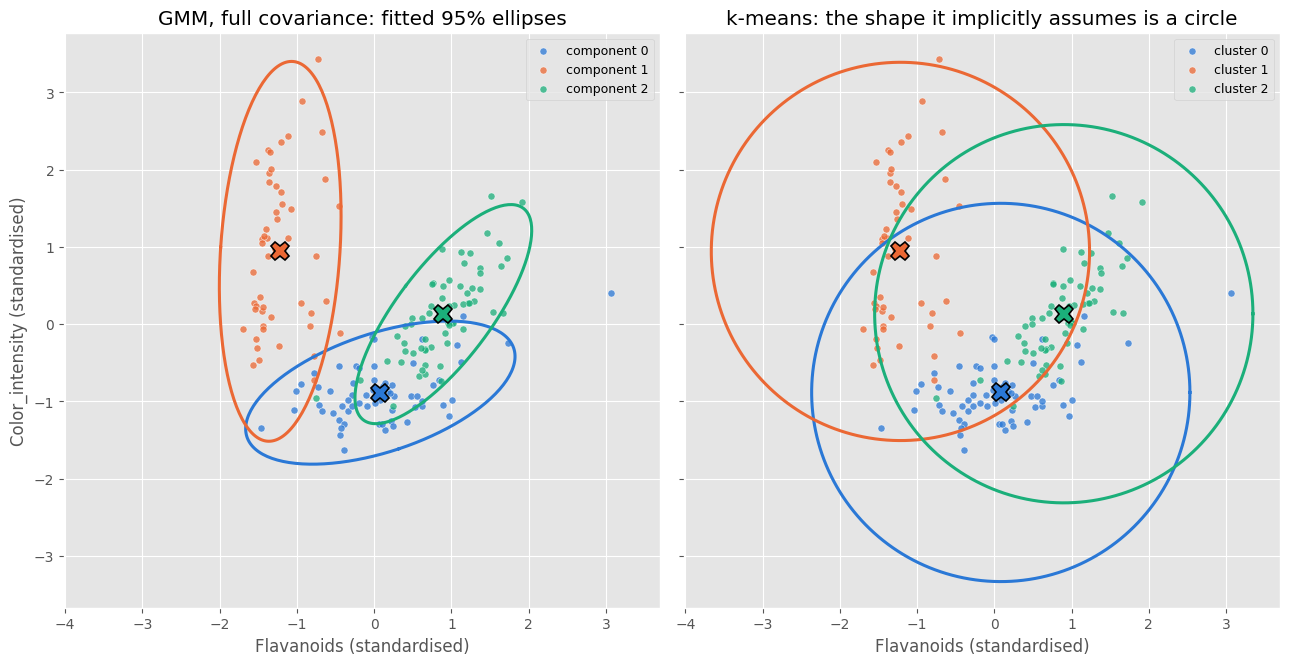

marginal 2x2 covariance of each fitted component, over these two features:
  component 0: axis lengths 0.74 x 0.31, major axis at -161.6 degrees, correlation +0.505
  component 1: axis lengths 1.01 x 0.32, major axis at  +86.2 degrees, correlation +0.186
  component 2: axis lengths 0.70 x 0.25, major axis at  +52.9 degrees, correlation +0.764


In [10]:
def covariance_ellipse(mean2, cov2, p=0.95, n=200):
    vals, vecs = np.linalg.eigh(cov2)             # ascending eigenvalues
    r2 = -2.0 * np.log(1.0 - p)                   # chi-squared, 2 dof
    t = np.linspace(0, 2 * np.pi, n)
    circle = np.column_stack([np.cos(t), np.sin(t)])
    pts = circle * np.sqrt(r2 * vals)[None, :]    # scale along each eigen-axis
    return pts @ vecs.T + mean2                   # rotate and translate


fi, fj = feature_names.index('Flavanoids'), feature_names.index('Color_intensity')
r2_95 = -2.0 * np.log(0.05)

fig, ax = plt.subplots(1, 2, figsize=(13, 6.5), sharex=True, sharey=True)

# equal aspect, so a circle is drawn as a circle and the ellipse shapes are honest
for a in ax:
    a.set_aspect('equal', adjustable='box')

for c in range(C_TRUE):
    m = gmm_pred == c
    ax[0].scatter(X[m, fi], X[m, fj], s=26, color=COLOURS[c], alpha=0.75,
                  edgecolors='white', linewidths=0.4, label='component %d' % c)
    S = gmm_full.covariances[c][np.ix_([fi, fj], [fi, fj])]
    e = covariance_ellipse(gmm_full.means[c][[fi, fj]], S)
    ax[0].plot(e[:, 0], e[:, 1], color=COLOURS[c], lw=2.2)
    ax[0].plot(*gmm_full.means[c][[fi, fj]], marker='X', ms=13, color=COLOURS[c],
               mec='black', mew=1.2)
ax[0].set_title('GMM, full covariance: fitted 95% ellipses')
ax[0].set_xlabel('Flavanoids (standardised)')
ax[0].set_ylabel('Color_intensity (standardised)')
ax[0].legend(loc='upper right', fontsize=9)

t = np.linspace(0, 2 * np.pi, 200)
for c in range(C_TRUE):
    m = km_labels == c
    ax[1].scatter(X[m, fi], X[m, fj], s=26, color=COLOURS[c], alpha=0.75,
                  edgecolors='white', linewidths=0.4, label='cluster %d' % c)
    cx, cy = km_centres[c][fi], km_centres[c][fj]
    ax[1].plot(cx + np.sqrt(r2_95) * np.cos(t), cy + np.sqrt(r2_95) * np.sin(t),
               color=COLOURS[c], lw=2.2)
    ax[1].plot(cx, cy, marker='X', ms=13, color=COLOURS[c], mec='black', mew=1.2)
ax[1].set_title('k-means: the shape it implicitly assumes is a circle')
ax[1].set_xlabel('Flavanoids (standardised)')
ax[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

print('marginal 2x2 covariance of each fitted component, over these two features:')
for c in range(C_TRUE):
    S = gmm_full.covariances[c][np.ix_([fi, fj], [fi, fj])]
    vals, vecs = np.linalg.eigh(S)
    angle = np.degrees(np.arctan2(vecs[1, -1], vecs[0, -1]))
    print('  component %d: axis lengths %.2f x %.2f, major axis at %+6.1f degrees, correlation %+.3f'
          % (c, np.sqrt(vals[-1]), np.sqrt(vals[0]), angle, S[0, 1] / np.sqrt(S[0, 0] * S[1, 1])))

## Soft assignments

The other thing a GMM produces that k-means cannot is a full probability vector per point. `gmm_full.resp` is
the $N \times C$ matrix of responsibilities; every row sums to 1, and `resp.max(axis=1)` is how confident the
model is about the point it is most sure of.

The left panel colours every point by its responsibility vector directly: the three component colours are
mixed in proportion to $\gamma_{i0}, \gamma_{i1}, \gamma_{i2}$, so a point the model is certain about comes out
as a pure component colour and an ambiguous one comes out as a visible blend. The wines below 0.99 confidence
are ringed and labelled. The right panel shows the same points under hard k-means labels, where every point
looks equally certain because the representation has nowhere to record doubt.

The panel underneath sorts all 178 wines by $1 - \max_c \gamma_{ic}$ on a log scale. This is the honest way to
show the distribution on this dataset: the components are well separated, so most wines are certain to within
float64 resolution, and only a handful carry real ambiguity. The curve falling across many orders of magnitude
is the information k-means throws away — every one of those points would be an identical hard label.

The printout lists the uncertain wines with their full responsibility vectors and their true cultivar.

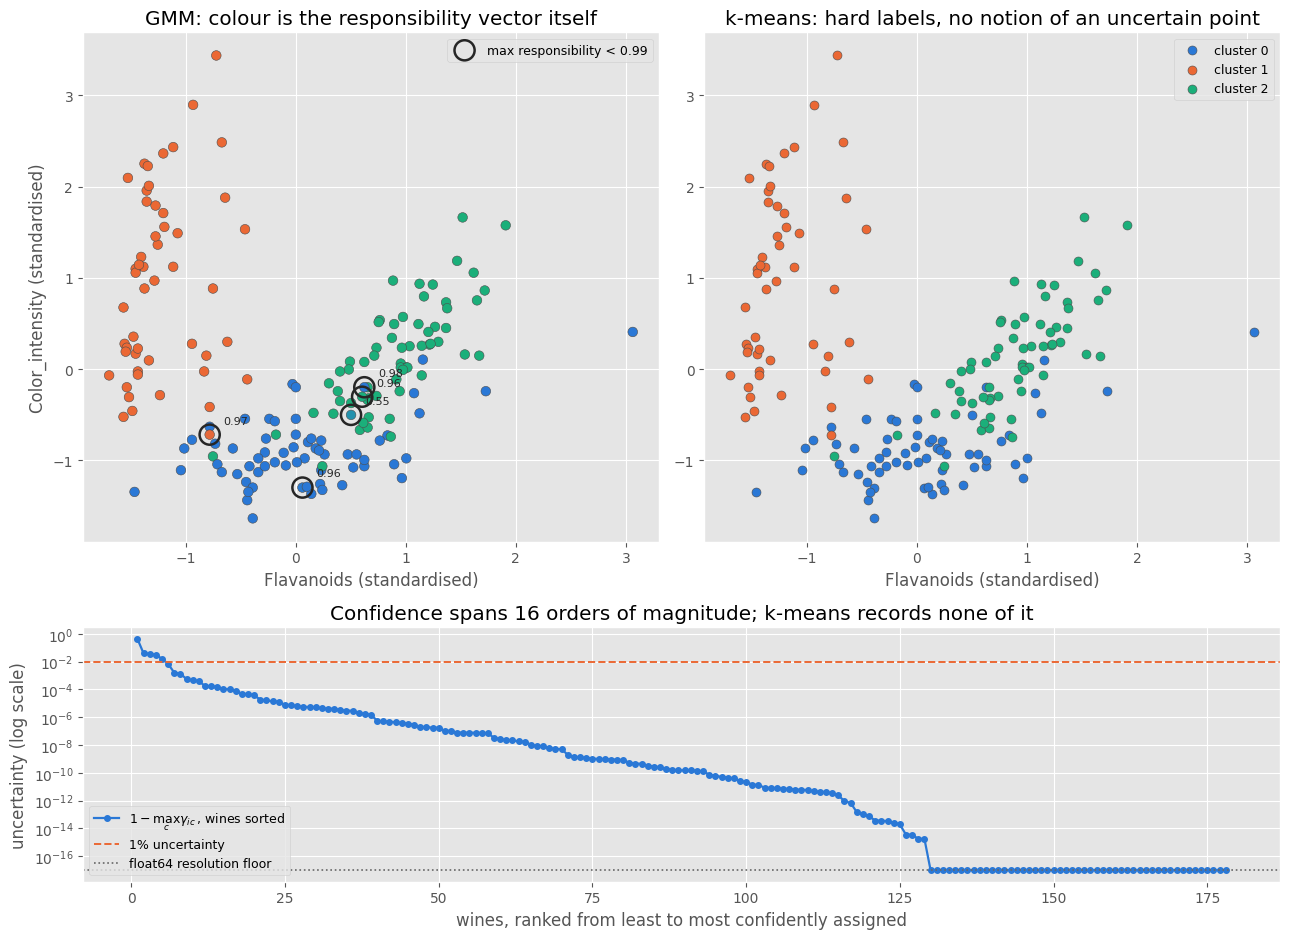

the 5 least certain wines (responsibility vector, mapped to cultivar order):
  idx   Cultivar 1  Cultivar 2  Cultivar 3  assigned      true
   81   0.4474     0.5526     0.0000     Cultivar 2    Cultivar 2
  117   0.0401     0.9599     0.0000     Cultivar 2    Cultivar 2
   43   0.9648     0.0352     0.0000     Cultivar 1    Cultivar 1
  118   0.0000     0.0309     0.9691     Cultivar 3    Cultivar 2
   65   0.0161     0.9839     0.0000     Cultivar 2    Cultivar 2

mean maximum responsibility 0.9967, minimum 0.5526
wines below 0.90: 1      wines below 0.99: 5


In [11]:
max_resp = gmm_full.resp.max(axis=1)
unsure = max_resp < 0.99

# colour each point by its responsibility vector: a blend of the three component
# colours weighted by gamma_ic, so an ambiguous point comes out a mixed colour
rgb = np.array([[0x2a, 0x78, 0xd6], [0xeb, 0x68, 0x34], [0x1b, 0xaf, 0x7a]]) / 255.0
blend = gmm_full.resp @ rgb

fig = plt.figure(figsize=(13, 9.5))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1])

ax0 = fig.add_subplot(gs[0, 0])
ax0.scatter(X[:, fi], X[:, fj], c=blend, s=48, edgecolors='0.3', linewidths=0.4)
ax0.scatter(X[unsure, fi], X[unsure, fj], s=210, facecolors='none',
            edgecolors='0.15', linewidths=1.8, label='max responsibility < 0.99')
for i in np.where(unsure)[0]:
    ax0.annotate('%.2f' % max_resp[i], (X[i, fi], X[i, fj]),
                 textcoords='offset points', xytext=(10, 8), fontsize=8, color='0.15')
ax0.set_xlabel('Flavanoids (standardised)')
ax0.set_ylabel('Color_intensity (standardised)')
ax0.set_title('GMM: colour is the responsibility vector itself')
ax0.legend(loc='upper right', fontsize=9)

ax1 = fig.add_subplot(gs[0, 1])
for c in range(C_TRUE):
    m = km_labels == c
    ax1.scatter(X[m, fi], X[m, fj], s=42, color=COLOURS[c], edgecolors='0.3',
                linewidths=0.4, label='cluster %d' % c)
ax1.set_xlabel('Flavanoids (standardised)')
ax1.set_title('k-means: hard labels, no notion of an uncertain point')
ax1.legend(loc='upper right', fontsize=9)

ax2 = fig.add_subplot(gs[1, :])
FLOOR = 1e-17
uncertainty = np.sort(1.0 - max_resp)[::-1]
ax2.semilogy(np.arange(1, N + 1), np.maximum(uncertainty, FLOOR), 'o-',
             color=COLOURS[0], lw=1.6, ms=4, label=r'$1 - \max_c \gamma_{ic}$, wines sorted')
ax2.axhline(0.01, color=COLOURS[1], lw=1.4, ls='--', label='1% uncertainty')
ax2.axhline(FLOOR, color='0.4', lw=1.2, ls=':', label='float64 resolution floor')
ax2.set_xlabel('wines, ranked from least to most confidently assigned')
ax2.set_ylabel('uncertainty (log scale)')
ax2.set_title('Confidence spans 16 orders of magnitude; k-means records none of it')
ax2.legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()

order = np.argsort(max_resp)
print('the %d least certain wines (responsibility vector, mapped to cultivar order):'
      % int(unsure.sum()))
print('  idx   ' + '  '.join('%-9s' % l for l in class_labels) + '  assigned      true')
inv = np.argsort(gmm_perm)
for i in order[:int(unsure.sum())]:
    r = gmm_full.resp[i][inv]
    print('  %3d   ' % i + '  '.join('%-9.4f' % v for v in r)
          + '  %-12s  %s' % (class_labels[gmm_mapped[i]], class_labels[y[i]]))
print()
print('mean maximum responsibility %.4f, minimum %.4f' % (max_resp.mean(), max_resp.min()))
print('wines below 0.90: %d      wines below 0.99: %d'
      % (int(np.sum(max_resp < 0.90)), int(np.sum(max_resp < 0.99))))

## Choosing the number of components with BIC

Nothing so far has justified $C = 3$; it was supplied. The log-likelihood cannot choose it, because adding
components can only increase the likelihood — more parameters always fit the same data at least as well. A
selection criterion has to charge for those parameters.

The Bayesian information criterion is

$$\text{BIC} = -2\log L + k\log N,$$

where $k$ is the number of free parameters and $N = 178$. Lower is better. The penalty $k \log N$ grows with
the parameter count, so BIC prefers the smallest model that explains the data.

Counting $k$ for $D = 13$ and $C = 3$. Mixing weights contribute $C - 1 = 2$, since they sum to 1. Means
contribute $CD = 39$. The covariances depend on the type:

| covariance | entries per component | $k$ at $C=3$, $D=13$ | $k\log N$ |
|---|---|---|---|
| full | $D(D+1)/2 = 91$ | $2 + 39 + 273 = 314$ | 1628 |
| diagonal | $D = 13$ | $2 + 39 + 39 = 80$ | 415 |
| spherical | $1$ | $2 + 39 + 3 = 44$ | 228 |

A full-covariance model at $C = 3$ spends 273 parameters on covariance alone, against 178 data points. That is
the tension BIC is meant to arbitrate.

The next cell fits every combination of $C = 1 \dots 8$ and the three covariance types and records the
log-likelihood, parameter count and BIC. It also records the smallest effective component size
$\min_c N_c$, because a full-covariance component needs at least $D + 1 = 14$ points before its scatter matrix
has full rank — below that the fit is being held up entirely by the ridge, and its log-likelihood is not
trustworthy.

In [12]:
c_range = np.arange(1, 9)
cov_types = ['full', 'diagonal', 'spherical']
sweep = {}

for ct in cov_types:
    ll_list, bic_list, k_list, minN_list = [], [], [], []
    for c in c_range:
        g = GMM(int(c), covariance_type=ct).fit(X)
        ll_list.append(g.loglik)
        bic_list.append(g.bic(X))
        k_list.append(g.n_parameters(D))
        minN_list.append(g.resp.sum(axis=0).min())
    sweep[ct] = {'ll': np.array(ll_list), 'bic': np.array(bic_list),
                 'k': np.array(k_list), 'minN': np.array(minN_list)}
    print('%s done' % ct)

print()
print('%-10s %2s %6s %11s %10s %10s' % ('cov type', 'C', 'k', 'log L', 'BIC', 'min N_c'))
for ct in cov_types:
    s = sweep[ct]
    for i, c in enumerate(c_range):
        flag = '  <- degenerate, min N_c < D+1' if (ct == 'full' and s['minN'][i] < D + 1) else ''
        print('%-10s %2d %6d %11.1f %10.1f %10.1f%s'
              % (ct, c, s['k'][i], s['ll'][i], s['bic'][i], s['minN'][i], flag))
    print()

best = {ct: int(c_range[np.argmin(sweep[ct]['bic'])]) for ct in cov_types}
overall_ct = min(cov_types, key=lambda ct: sweep[ct]['bic'].min())
print('minimum-BIC number of components by covariance type:')
for ct in cov_types:
    print('  %-10s C = %d   (BIC %.1f)' % (ct, best[ct], sweep[ct]['bic'].min()))
print()
print('lowest BIC over all models: %s covariance with C = %d, BIC %.1f'
      % (overall_ct, best[overall_ct], sweep[overall_ct]['bic'].min()))

full done


diagonal done


spherical done

cov type    C      k       log L        BIC    min N_c
full        1    104     -2601.2     5741.3      178.0
full        2    209     -2262.7     5608.3       52.9
full        3    314     -2089.6     5806.3       51.0
full        4    419     -1984.1     6139.4       20.0
full        5    524     -1860.1     6435.4       24.0
full        6    629     -1743.5     6746.4       15.0
full        7    734     -1617.0     7037.3       14.0  <- degenerate, min N_c < D+1
full        8    839     -1347.7     7042.9        5.0  <- degenerate, min N_c < D+1

diagonal    1     26     -3283.4     6701.6      178.0
diagonal    2     53     -2853.6     5981.8       55.6
diagonal    3     80     -2564.4     5543.4       51.1
diagonal    4    107     -2515.6     5585.7       23.8
diagonal    5    134     -2462.8     5620.0       18.4
diagonal    6    161     -2409.0     5652.3       12.0
diagonal    7    188     -2349.7     5673.5       17.7
diagonal    8    215     -2273.9     5662.0

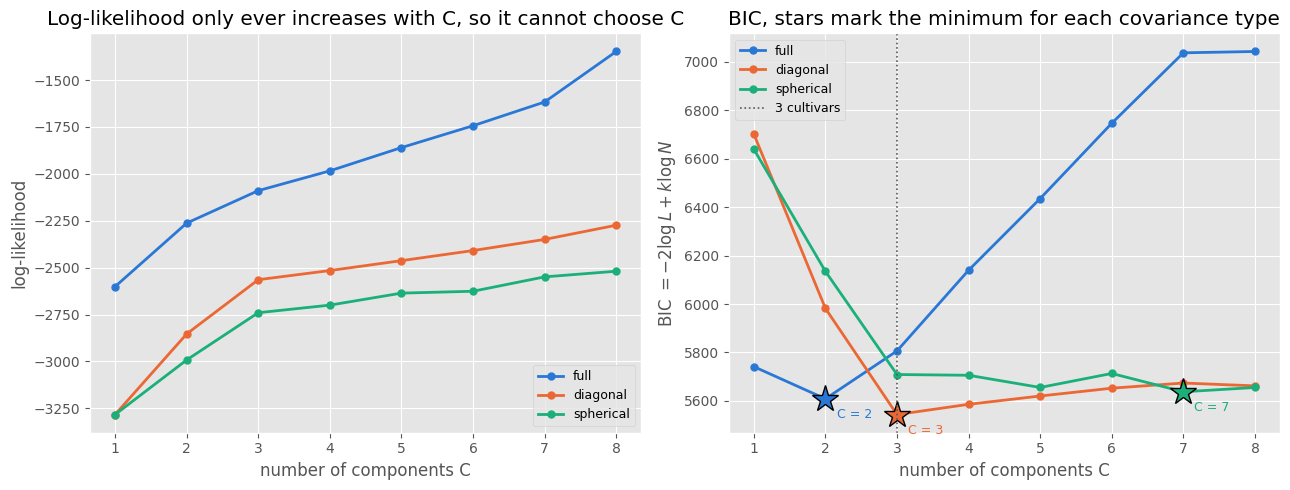

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

for ct, col in zip(cov_types, COLOURS):
    ax[0].plot(c_range, sweep[ct]['ll'], 'o-', color=col, lw=2, ms=5, label=ct)
ax[0].set_xlabel('number of components C')
ax[0].set_ylabel('log-likelihood')
ax[0].set_title('Log-likelihood only ever increases with C, so it cannot choose C')
ax[0].legend(loc='lower right', fontsize=9)

for ct, col in zip(cov_types, COLOURS):
    ax[1].plot(c_range, sweep[ct]['bic'], 'o-', color=col, lw=2, ms=5, label=ct)
    cbest = int(c_range[np.argmin(sweep[ct]['bic'])])
    ax[1].plot(cbest, sweep[ct]['bic'].min(), marker='*', ms=20, color=col,
               mec='black', mew=1.0)
    ax[1].annotate('C = %d' % cbest, (cbest, sweep[ct]['bic'].min()),
                   textcoords='offset points', xytext=(8, -14), fontsize=9, color=col)
ax[1].axvline(C_TRUE, color='0.35', lw=1.2, ls=':', label='3 cultivars')
ax[1].set_xlabel('number of components C')
ax[1].set_ylabel(r'BIC $= -2\log L + k\log N$')
ax[1].set_title('BIC, stars mark the minimum for each covariance type')
ax[1].legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

### What the BIC curve says

Read the printout and the right-hand panel together, because the answer depends on the covariance type and it
would be misleading to quote only the flattering one.

With **full** covariance BIC prefers $C = 2$, not 3. Each extra full-covariance component costs
$91 + 13 + 1 = 105$ parameters, and $105\log 178 = 544$ BIC units, so the third component would have to buy
more than 272 nats of log-likelihood to pay for itself. It buys about 173, so BIC declines. The full-covariance
curve also cannot be trusted at the top end: by $C = 8$ the smallest component holds fewer than $D + 1 = 14$
effective points, so its covariance is rank-deficient and the log-likelihood it reports is an artefact of the
ridge.

With **diagonal** covariance, where each extra component costs only 27 parameters, BIC has a clear minimum at
$C = 3$, and that minimum is the lowest BIC of any model tried. The **spherical** curve nominally bottoms out
at $C = 7$, but it is essentially flat from $C = 3$ onwards — the spread across $C = 3 \dots 8$ is about 75 BIC
units against a drop of 930 from $C = 1$ to $C = 3$ — so that minimum is not a meaningful choice, and a
spherical model is in any case too restrictive to describe these clusters. So the answer to whether BIC recovers three
components is: yes, but only once the model is not being charged for 273 covariance parameters it does not have
the data to support. That is a statement about $N = 178$ in $D = 13$ as much as about the wines.

Choosing $C$ this way still means fitting eight models and comparing them. A Dirichlet process mixture infers
the number of occupied components as part of a single fit instead, and
`dirichlet_process_mixture_from_scratch.ipynb` in this repository does that on the same dataset.

## Full against diagonal covariance

Both were fitted in the sweep; the cell below refits the three types at $C = 3$ and compares them directly on
agreement with the cultivars, log-likelihood, parameter count and BIC. The question is what the 234 extra
parameters that `full` spends over `diagonal` actually buy.

The answer on this dataset is worth stating carefully. Full covariance wins clearly on log-likelihood, which is
expected and not evidence of anything — it is a strictly larger model class containing the diagonal one, and
the likelihood is exactly what EM maximises. It does not win on agreement with the cultivars, where the
diagonal model is in fact two wines better, and it loses on BIC by a wide margin. Fitting 234 extra
off-diagonal terms describes the data in hand more closely while making the model harder to justify at
$N = 178$. The `spherical` row is included as the far end of the same trade-off.

cov type     params        log L      BIC  agreement    iters
full            314      -2089.6     5806.3    0.9607       9
diagonal         80      -2564.4     5543.4    0.9719      16
spherical        44      -2740.4     5708.8    0.9607      10
k-means          39            -          -    0.9607       -

full spends 234 more parameters than diagonal and gains 474.8 log-likelihood units,
which BIC charges 1212.5 for. Net BIC change: +262.9


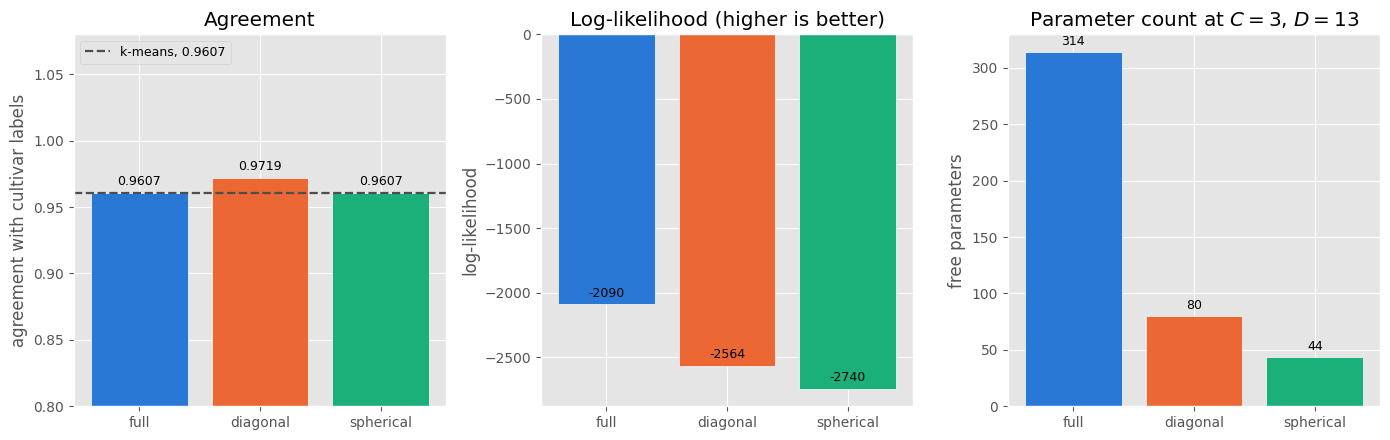

In [14]:
models = {}
for ct in cov_types:
    g = GMM(C_TRUE, covariance_type=ct).fit(X)
    pred = g.predict(X)
    sc, perm = best_match(pred, y, C_TRUE)
    models[ct] = {'model': g, 'score': sc, 'mapped': perm[pred],
                  'k': g.n_parameters(D), 'll': g.loglik, 'bic': g.bic(X)}

print('%-10s %8s %12s %8s %10s %8s' % ('cov type', 'params', 'log L', 'BIC', 'agreement', 'iters'))
for ct in cov_types:
    m = models[ct]
    print('%-10s %8d %12.1f %10.1f %9.4f %7d'
          % (ct, m['k'], m['ll'], m['bic'], m['score'], m['model'].n_iter))
print('%-10s %8d %12s %10s %9.4f %7s' % ('k-means', C_TRUE * D, '-', '-', km_score, '-'))
print()
print('full spends %d more parameters than diagonal and gains %.1f log-likelihood units,'
      % (models['full']['k'] - models['diagonal']['k'],
         models['full']['ll'] - models['diagonal']['ll']))
print('which BIC charges %.1f for. Net BIC change: %+.1f'
      % ((models['full']['k'] - models['diagonal']['k']) * np.log(N),
         models['full']['bic'] - models['diagonal']['bic']))

fig, ax = plt.subplots(1, 3, figsize=(14, 4.5))
names = cov_types

ax[0].bar(names, [models[c]['score'] for c in names], color=COLOURS, edgecolor='white')
ax[0].axhline(km_score, color='0.3', lw=1.6, ls='--', label='k-means, %.4f' % km_score)
for i, c in enumerate(names):
    ax[0].text(i, models[c]['score'] + 0.006, '%.4f' % models[c]['score'], ha='center', fontsize=9)
ax[0].set_ylim(0.8, 1.08)
ax[0].set_ylabel('agreement with cultivar labels')
ax[0].set_title('Agreement')
ax[0].legend(loc='upper left', fontsize=9)

ax[1].bar(names, [models[c]['ll'] for c in names], color=COLOURS, edgecolor='white')
for i, c in enumerate(names):
    ax[1].text(i, models[c]['ll'] + 60, '%.0f' % models[c]['ll'], ha='center', fontsize=9)
ax[1].set_ylabel('log-likelihood')
ax[1].set_title('Log-likelihood (higher is better)')

ax[2].bar(names, [models[c]['k'] for c in names], color=COLOURS, edgecolor='white')
for i, c in enumerate(names):
    ax[2].text(i, models[c]['k'] + 6, '%d' % models[c]['k'], ha='center', fontsize=9)
ax[2].set_ylabel('free parameters')
ax[2].set_title(r'Parameter count at $C=3$, $D=13$')

plt.tight_layout()
plt.show()

## Agreement with the held-back cultivars

The cross-tabs below put the true cultivar on the rows and the assigned cluster on the columns, after the
label permutation from `best_match`. A perfect clustering would be diagonal. Counts are annotated in every
cell and the off-diagonal entries are the disagreements.

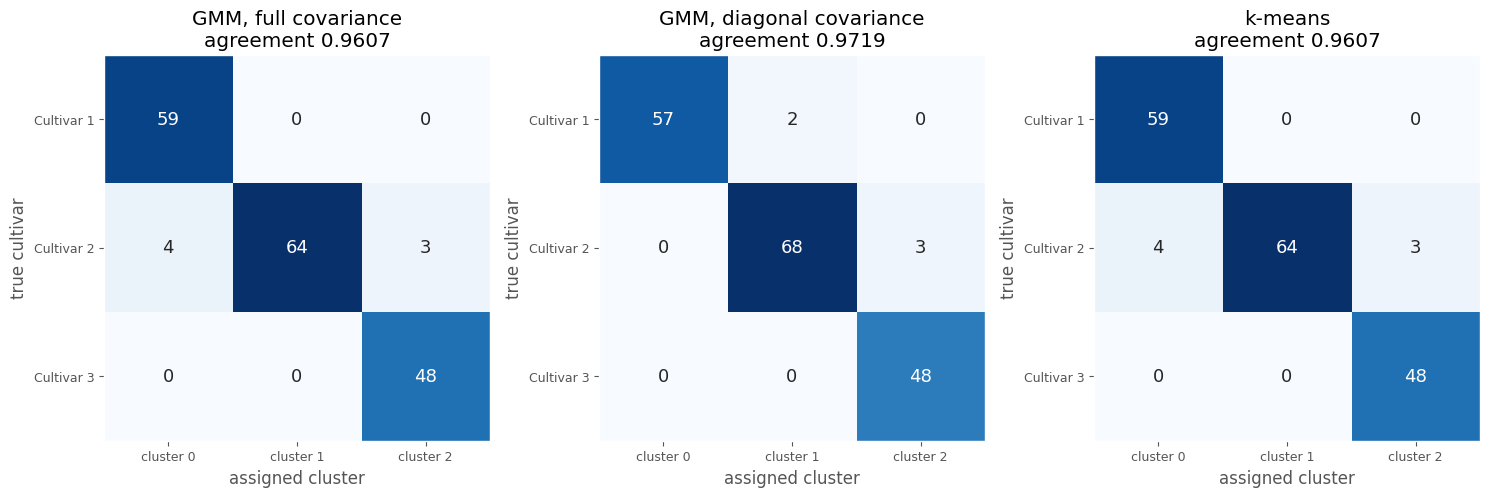

GMM, full covariance        correct 171 / 178   disagreements 7
GMM, diagonal covariance    correct 173 / 178   disagreements 5
k-means                     correct 171 / 178   disagreements 7


In [15]:
def cross_tab(mapped, truth, k):
    M = np.zeros((k, k), dtype=int)
    for a, b in zip(truth, mapped):
        M[a, b] += 1
    return M


tabs = [('GMM, full covariance', cross_tab(gmm_mapped, y, C_TRUE), gmm_score),
        ('GMM, diagonal covariance', cross_tab(models['diagonal']['mapped'], y, C_TRUE),
         models['diagonal']['score']),
        ('k-means', cross_tab(km_mapped, y, C_TRUE), km_score)]

fig, ax = plt.subplots(1, 3, figsize=(15, 4.8))
for a, (name, M, sc) in zip(ax, tabs):
    a.imshow(M, cmap='Blues', vmin=0, vmax=M.max())
    for i in range(C_TRUE):
        for j in range(C_TRUE):
            a.text(j, i, str(M[i, j]), ha='center', va='center', fontsize=13,
                   color='white' if M[i, j] > M.max() * 0.55 else '0.15')
    a.set_xticks(range(C_TRUE))
    a.set_yticks(range(C_TRUE))
    a.set_xticklabels(['cluster %d' % c for c in range(C_TRUE)], fontsize=9)
    a.set_yticklabels(class_labels, fontsize=9)
    a.set_xlabel('assigned cluster')
    a.set_ylabel('true cultivar')
    a.set_title('%s\nagreement %.4f' % (name, sc))
    a.grid(False)

plt.tight_layout()
plt.show()

for name, M, sc in tabs:
    print('%-26s  correct %3d / %d   disagreements %d'
          % (name, int(np.trace(M)), N, int(M.sum() - np.trace(M))))

## The singularity: why maximum likelihood for a GMM is ill-posed

This is a real pathology of the model, not an implementation detail, and it is worth demonstrating rather than
mentioning.

Take a fitted mixture and move one component's mean exactly onto a data point $\mathbf{x}_1$, then set that
component's covariance to $\sigma^2 I$ and shrink $\sigma$. The density that component assigns to $\mathbf{x}_1$
is

$$\mathcal{N}(\mathbf{x}_1 \mid \mathbf{x}_1, \sigma^2 I) = (2\pi\sigma^2)^{-D/2},$$

so that single point contributes $\log \pi_1 - \tfrac{D}{2}\log(2\pi\sigma^2)$ to the log-likelihood, which
grows like $-D\log\sigma$ and is unbounded above. Every other point loses whatever that component was
contributing, but that loss is finite and bounded, because the remaining components still cover them. The total
therefore diverges:

$$\lim_{\sigma \to 0} \log L = +\infty.$$

The supremum of the likelihood is infinite, and it is attained by a solution that has wrapped one component
around a single wine and learned nothing. Any GMM fit worth having is a local optimum. This is the reason the
`reg` ridge exists: `_shape` adds `1e-6 * np.eye(D)` to every covariance, which puts a hard floor of
$\sigma^2 \ge 10^{-6}$ under the shrinkage and makes the collapse unreachable.

The cell below sweeps $\sigma$ from $1$ down to $10^{-150}$ with the ridge switched off and evaluates the
log-likelihood at each value. It also finds the $\sigma$ at which the degenerate configuration overtakes the
proper fit from earlier in the notebook — the point past which the "better" model by likelihood is the useless one.

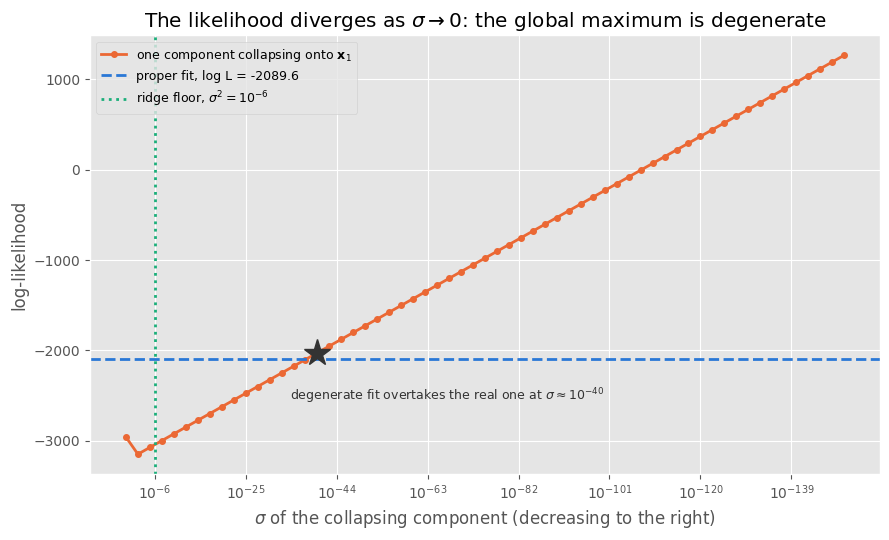

sigma        log-likelihood
  1e0          -2958.9
  1e-25        -2475.0
  1e-50        -1726.6
  1e-75         -978.3
  1e-100        -230.0
  1e-125         518.4
  1e-150        1266.7

proper fit log-likelihood                 -2089.6
degenerate fit passes it at sigma ~= 1.0e-40
log-likelihood still rising at sigma = 1e-150: 1266.7, gaining 29.9 per decade

with reg = 1e-6 the covariance cannot go below that floor, so this branch is unreachable.


In [16]:
degenerate = GMM(C_TRUE, covariance_type='full', reg=0.0)
degenerate.weights = gmm_full.weights.copy()
degenerate.means = gmm_full.means.copy()
degenerate.covariances = gmm_full.covariances.copy()
degenerate.means[0] = X[0]                        # component 0 sits on wine 0

sigmas = np.logspace(0, -150, 61)
ll_sigma = np.zeros(len(sigmas))
for i, s in enumerate(sigmas):
    degenerate.covariances[0] = (s ** 2) * np.eye(D)
    ll_sigma[i] = degenerate.score(X)

crossing = np.where(ll_sigma > gmm_full.loglik)[0]
sigma_cross = sigmas[crossing[0]] if len(crossing) else None

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(sigmas, ll_sigma, 'o-', color=COLOURS[1], lw=2, ms=4,
        label=r'one component collapsing onto $\mathbf{x}_1$')
ax.axhline(gmm_full.loglik, color=COLOURS[0], lw=2, ls='--',
           label='proper fit, log L = %.1f' % gmm_full.loglik)
ax.axvline(1e-6, color=COLOURS[2], lw=2, ls=':',
           label=r'ridge floor, $\sigma^2 = 10^{-6}$')
if sigma_cross is not None:
    ax.plot(sigma_cross, ll_sigma[crossing[0]], marker='*', ms=20, color='0.2')
    ax.annotate(r'degenerate fit overtakes the real one at $\sigma \approx 10^{%d}$'
                % int(round(np.log10(sigma_cross))),
                (sigma_cross, ll_sigma[crossing[0]]), textcoords='offset points',
                xytext=(-20, -34), fontsize=9, color='0.2')
ax.set_xscale('log')
ax.invert_xaxis()
ax.set_xlabel(r'$\sigma$ of the collapsing component (decreasing to the right)')
ax.set_ylabel('log-likelihood')
ax.set_title(r'The likelihood diverges as $\sigma \to 0$: the global maximum is degenerate')
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

print('sigma        log-likelihood')
for i in range(0, len(sigmas), 10):
    print('  1e%-6d  %10.1f' % (round(np.log10(sigmas[i])), ll_sigma[i]))
print()
print('proper fit log-likelihood                 %.1f' % gmm_full.loglik)
if sigma_cross is not None:
    print('degenerate fit passes it at sigma ~= %.1e' % sigma_cross)
print('log-likelihood still rising at sigma = 1e-150: %.1f, gaining %.1f per decade'
      % (ll_sigma[-1], D * np.log(10) / 2 * 2))
print()
print('with reg = 1e-6 the covariance cannot go below that floor, so this branch is unreachable.')

## Summary

What the fit produced on 178 wines in 13 standardised dimensions:

- **EM converged in a small number of iterations** from the k-means initialisation, with the log-likelihood
  non-decreasing at every step and the responsibilities summing to 1 for every point. Both are asserted in the
  code, not just plotted.
- **The initialisation matters more than anything else.** Every random start reached a worse local optimum than
  the k-means start, by a wide margin in both log-likelihood and agreement with the cultivars. EM guarantees
  monotone improvement, not a good answer.
- **GMM and k-means produce the same partition here.** Both agree with the cultivars on 171 of 178 wines. The
  wine data is easy and the clusters are well separated, so there is no accuracy win to report, and inventing
  one would be dishonest. What the GMM adds is visible elsewhere: the fitted ellipses have distinct orientations
  and aspect ratios that k-means' implicit circle cannot represent, and the responsibilities identify the small
  number of wines that sit genuinely between components.
- **Full covariance buys likelihood, not agreement.** It fits 314 parameters against diagonal's 80 and gains
  475 log-likelihood units, but agrees with the cultivars on two wines fewer and is penalised 1212 BIC units
  for the extra parameters, a net BIC loss of 263. At $N = 178$ and $D = 13$ there is not enough data to
  justify 91 covariance entries per component.
- **BIC recovers three components for the diagonal model**, and that model has the lowest BIC of anything tried.
  For the full model BIC prefers two. The honest summary is that BIC finds three only when the model is not
  overparameterised for the sample size.
- **The numerics are not optional.** The naive product of the per-point mixture densities reaches exactly 0.0
  in float64 partway through the dataset; the log-space computation returns a finite number for all 178. And
  with the ridge removed, the likelihood provably diverges as a component collapses onto a single point, so the
  global maximum of the objective is a solution that explains nothing.

The two structural limitations left are that $C$ has to be chosen from outside, by fitting a grid of models and
comparing BIC, and that the covariance type has to be chosen the same way. A Dirichlet process mixture addresses
the first by inferring the number of occupied components within a single fit.